In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

All calculations here are based on the days with >= 70% CGM data coverage.

In [7]:
import pandas as pd
import numpy as np

def time_in_range_per_day(file_path, threshold=15):
    """
    Calculates the number of minutes per day where BG readings are in the 70–180 mg/dL range.

    Parameters
    ----------
    file_path : str
        Path to the CSV file containing 'timestamp' and 'BGvalue' columns.
    threshold : int, optional
        Maximum gap (in minutes) allowed between consecutive readings to cap time contribution.
        Default is 15 minutes.

    Returns
    -------
    pd.DataFrame
        A DataFrame with columns:
        - 'date': date of recording
        - 'in_range_minutes': total minutes in [70, 180] range that day
        - 'total_minutes': total CGM minutes that day (capped)
        - 'in_range_ratio': proportion of time in target range
    """
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")
        return [], [], []

    # Skip files with no data (only headers or empty content)
    if df.empty or len(df.columns) < 3:  # Ensure at least 'timestamp', 'BGvalue', and 'date' columns exist
        print(f"Skipping empty or invalid file: {file_path}")
        return [], [], []
    
    df = pd.read_csv(file_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', format='mixed')
    df = df.dropna(subset=['timestamp', 'BGvalue'])
    df['date'] = df['timestamp'].dt.date
    df = df.sort_values('timestamp')

    df['BGvalue'] = pd.to_numeric(df['BGvalue'], errors='coerce')
    df = df.dropna(subset=['BGvalue'])

    results = []

    for date, group in df.groupby('date'):
        group = group.sort_values('timestamp').reset_index(drop=True)

        # Compute time gaps (minutes) between consecutive readings
        time_diffs = group['timestamp'].diff().dt.total_seconds().div(60).iloc[1:]  # skip first NaN
        capped_diffs = np.minimum(time_diffs, threshold)

        # Align BG values with time gaps (use second reading in each pair)
        bg_values = group['BGvalue'].iloc[1:].values
        in_range_mask = (bg_values >= 70) & (bg_values <= 180)

        in_range_minutes = capped_diffs[in_range_mask].sum()
        total_minutes = capped_diffs.sum()
        in_range_ratio = 100*in_range_minutes / total_minutes if total_minutes > 0 else 0.0
        daily_mean_bg = group['BGvalue'].mean()
        daily_gly_var = group['BGvalue'].std() *100 / daily_mean_bg

        results.append({
            'date': date,
            'in_range_minutes': round(in_range_minutes, 1),
            'total_minutes': round(total_minutes, 1),
            'in_range_ratio': round(in_range_ratio, 2),
            'daily_mean_bg': round(daily_mean_bg, 1),
            'daily_gly_var': round(daily_gly_var, 2)
        })
    result_df = pd.DataFrame(results)

    return result_df['in_range_ratio'].to_list(), result_df['daily_mean_bg'].to_list(), result_df['daily_gly_var'].to_list()


# OhioT1DM

In [ ]:
# Folder path
# 2018
folder_path_2018_test = '../high_processed_OhioT1DM/2018/test'
folder_path_2018_train = '../high_processed_OhioT1DM/2018/train'
# List all files in the folder
file_names_2018_test = [f for f in os.listdir(folder_path_2018_test) if os.path.isfile(os.path.join(folder_path_2018_test, f))]
file_names_2018_train = [f for f in os.listdir(folder_path_2018_train) if os.path.isfile(os.path.join(folder_path_2018_train, f))]


# 2020
folder_path_2020_test = '../high_processed_OhioT1DM/2020/test'
folder_path_2020_train = '../high_processed_OhioT1DM/2020/train'
file_names_2020_test = [f for f in os.listdir(folder_path_2020_test) if os.path.isfile(os.path.join(folder_path_2020_test, f))]
file_names_2020_train = [f for f in os.listdir(folder_path_2020_train) if os.path.isfile(os.path.join(folder_path_2020_train, f))]

total_tir_ratio_ohio = []
total_mean_bg_ohio = []
total_gv_ohio = []

# Loop over DataFrames and accumulate counts
# Process files in the train folder
for input_file in file_names_2018_train:
    # Parse the CSV file
    if input_file != ".DS_Store":
        full_file_path = os.path.join(folder_path_2018_train, input_file)
        result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
        total_tir_ratio_ohio += result_list
        total_mean_bg_ohio += result_mean_bg
        total_gv_ohio += result_gv

for input_file in file_names_2018_test:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_2018_test, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_ohio += result_list
    total_mean_bg_ohio += result_mean_bg
    total_gv_ohio += result_gv

for input_file in file_names_2020_train:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_2020_train, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_ohio += result_list
    total_mean_bg_ohio += result_mean_bg
    total_gv_ohio += result_gv

for input_file in file_names_2020_test:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_2020_test, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_ohio += result_list
    total_mean_bg_ohio += result_mean_bg
    total_gv_ohio += result_gv

# T1DEXI

In [ ]:
folder_path_t1dexi = '../high_processed_T1DEXI/'
file_names_t1dexi= [f for f in os.listdir(folder_path_t1dexi) if os.path.isfile(os.path.join(folder_path_t1dexi, f))]

total_tir_ratio_t1dexi = []
total_mean_bg_t1dexi = []
total_gv_t1dexi = []

for input_file in file_names_t1dexi:
    full_file_path = os.path.join(folder_path_t1dexi, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_t1dexi += result_list
    total_mean_bg_t1dexi += result_mean_bg
    total_gv_t1dexi += result_gv

Skipping empty or invalid file: ./high_processed_T1DEXI/filtered_329.csv
Skipping empty or invalid file: ./high_processed_T1DEXI/filtered_1606.csv
Skipping empty or invalid file: ./high_processed_T1DEXI/filtered_1118.csv
Skipping empty or invalid file: ./high_processed_T1DEXI/filtered_1093.csv
Skipping empty or invalid file: ./high_processed_T1DEXI/filtered_323.csv


# BIL

In [ ]:
folder_path_BIL = '../high_processed_BIL/'
file_names_BIL = [f for f in os.listdir(folder_path_BIL) if os.path.isfile(os.path.join(folder_path_BIL, f))]

total_tir_ratio_BIL = []
total_mean_bg_BIL = []
total_gv_BIL = []

for input_file in file_names_BIL:
    full_file_path = os.path.join(folder_path_BIL, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_BIL += result_list
    total_mean_bg_BIL += result_mean_bg
    total_gv_BIL += result_gv

# DiaTrend

In [ ]:
folder_path_Diatrend = '../high_processed_Diatrend/'
file_names_Diatrend = [f for f in os.listdir(folder_path_Diatrend) if os.path.isfile(os.path.join(folder_path_Diatrend, f))]

total_tir_ratio_Diatrend = []
total_mean_bg_Diatrend = []
total_gv_Diatrend = []

for input_file in file_names_Diatrend:
    full_file_path = os.path.join(folder_path_Diatrend, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_Diatrend += result_list
    total_mean_bg_Diatrend += result_mean_bg
    total_gv_Diatrend += result_gv

# ShanghaiT1DM

In [ ]:
folder_path_shanghait1 = '../high_processed_shanghait1dm/'
file_names_shanghait1 = [f for f in os.listdir(folder_path_shanghait1) if os.path.isfile(os.path.join(folder_path_shanghait1, f))]

total_tir_ratio_shanghait1 = []
total_mean_bg_shanghait1 = []
total_gv_shanghait1 = []

for input_file in file_names_shanghait1:
    full_file_path = os.path.join(folder_path_shanghait1, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_shanghait1 += result_list
    total_mean_bg_shanghait1 += result_mean_bg
    total_gv_shanghait1 += result_gv

# ShanghaiT2DM

In [ ]:
folder_path_shanghait2 = '../high_processed_shanghait2dm/'
file_names_shanghait2 = [f for f in os.listdir(folder_path_shanghait2) if os.path.isfile(os.path.join(folder_path_shanghait2, f))]

total_tir_ratio_shanghait2 = []
total_mean_bg_shanghait2 = []
total_gv_shanghait2 = []

for input_file in file_names_shanghait2:
    full_file_path = os.path.join(folder_path_shanghait2, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_shanghait2 += result_list
    total_mean_bg_shanghait2 += result_mean_bg
    total_gv_shanghait2 += result_gv

# T1DiabetesGranada

In [ ]:
folder_path_t1diabetesgranada = '../high_processed_T1DiabetesGranada/'
file_names_t1diabetesgranada = [f for f in os.listdir(folder_path_t1diabetesgranada) if os.path.isfile(os.path.join(folder_path_t1diabetesgranada, f))]

total_tir_ratio_t1diabetesgranada = []
total_mean_bg_t1diabetesgranada = []
total_gv_t1diabetesgranada = []

for input_file in file_names_t1diabetesgranada:
    full_file_path = os.path.join(folder_path_t1diabetesgranada, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_t1diabetesgranada += result_list
    total_mean_bg_t1diabetesgranada += result_mean_bg
    total_gv_t1diabetesgranada += result_gv

Skipping empty or invalid file: ./high_processed_T1DiabetesGranada/filtered_LIB193713.csv


# AI-READI

In [ ]:
folder_path_aireadi = '../high_processed_aireadi/'
file_names_aireadi = [f for f in os.listdir(folder_path_aireadi) if os.path.isfile(os.path.join(folder_path_aireadi, f))]

total_tir_ratio_aireadi = []
total_mean_bg_aireadi = []
total_gv_aireadi = []

for input_file in file_names_aireadi:
    full_file_path = os.path.join(folder_path_aireadi, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_aireadi += result_list
    total_mean_bg_aireadi += result_mean_bg
    total_gv_aireadi += result_gv

Skipping empty or invalid file: ./high_processed_aireadi/filtered_4034_DEX.csv
Skipping empty or invalid file: ./high_processed_aireadi/filtered_1111_DEX.csv
Skipping empty or invalid file: ./high_processed_aireadi/filtered_7052_DEX.csv
Skipping empty or invalid file: ./high_processed_aireadi/filtered_7009_DEX.csv
Skipping empty or invalid file: ./high_processed_aireadi/filtered_7008_DEX.csv


# UCHTT1DM

In [ ]:
folder_path_uchtt1dm = '../high_processed_UCHTT1DM/'
file_names_uchtt1dm = [f for f in os.listdir(folder_path_uchtt1dm) if os.path.isfile(os.path.join(folder_path_uchtt1dm, f))]

total_tir_ratio_uchtt1dm = []
total_mean_bg_uchtt1dm = []
total_gv_uchtt1dm = []

for input_file in file_names_uchtt1dm:
    full_file_path = os.path.join(folder_path_uchtt1dm, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_uchtt1dm += result_list
    total_mean_bg_uchtt1dm += result_mean_bg
    total_gv_uchtt1dm += result_gv

# CGMacros

In [ ]:
folder_path_CGMacros_dexcom = '../high_processed_cgmacros/Dexcom GL'
file_names_CGMacros_dexcom = [f for f in os.listdir(folder_path_CGMacros_dexcom) if os.path.isfile(os.path.join(folder_path_CGMacros_dexcom, f))]
folder_path_CGMacros_libre = '../high_processed_cgmacros/Libre GL'
file_names_CGMacros_libre = [f for f in os.listdir(folder_path_CGMacros_libre) if os.path.isfile(os.path.join(folder_path_CGMacros_libre, f))]

total_tir_ratio_cgmacros = []
total_mean_bg_cgmacros = []
total_gv_cgmacros = []

for input_file in file_names_CGMacros_dexcom:
    full_file_path = os.path.join(folder_path_CGMacros_dexcom, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_cgmacros += result_list
    total_mean_bg_cgmacros += result_mean_bg
    total_gv_cgmacros += result_gv

for input_file in file_names_CGMacros_libre:
    full_file_path = os.path.join(folder_path_CGMacros_libre, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_cgmacros += result_list
    total_mean_bg_cgmacros += result_mean_bg
    total_gv_cgmacros += result_gv

# Figure

/var/folders/j5/tbqtlr256g5b8t969rk8d5kr0000gn/T/ipykernel_94931/1609697360.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='group', y='value', data=df, inner='box', palette='Set2')


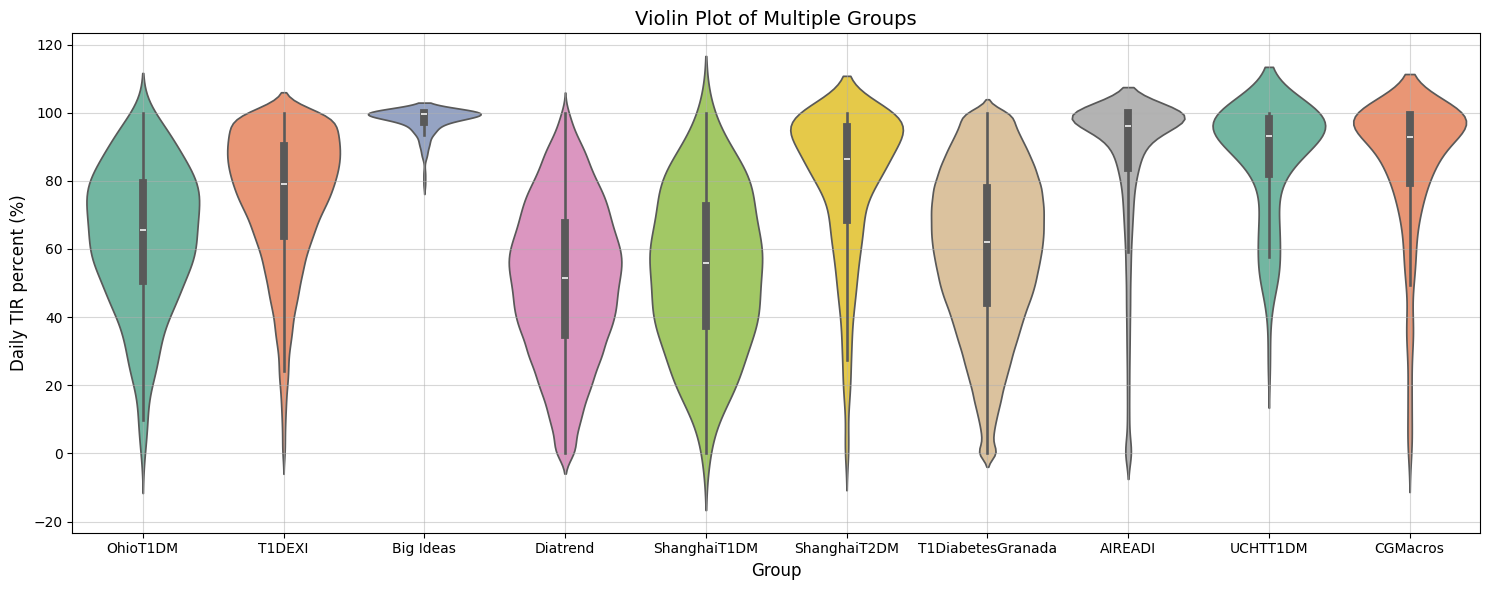

In [21]:
import seaborn as sns

# Put all data into a long-form DataFrame
df = pd.DataFrame({
    'value': total_tir_ratio_ohio + total_tir_ratio_t1dexi + total_tir_ratio_BIL + total_tir_ratio_Diatrend + total_tir_ratio_shanghait1 + total_tir_ratio_shanghait2 + total_tir_ratio_t1diabetesgranada + total_tir_ratio_aireadi + total_tir_ratio_uchtt1dm + total_tir_ratio_cgmacros,
    'group': ['OhioT1DM'] * len(total_tir_ratio_ohio) + ['T1DEXI'] * len(total_tir_ratio_t1dexi) + ['Big Ideas'] * len(total_tir_ratio_BIL) + ['Diatrend'] * len(total_tir_ratio_Diatrend) + ['ShanghaiT1DM'] * len(total_tir_ratio_shanghait1) + ['ShanghaiT2DM'] * len(total_tir_ratio_shanghait2) + ['T1DiabetesGranada'] * len(total_tir_ratio_t1diabetesgranada) + ['AIREADI'] * len(total_tir_ratio_aireadi) + ['UCHTT1DM'] * len(total_tir_ratio_uchtt1dm) + ['CGMacros'] * len(total_tir_ratio_cgmacros)
})

# Plot
plt.figure(figsize=(15, 6))
sns.violinplot(x='group', y='value', data=df, inner='box', palette='Set2')

# Labels and title
plt.xlabel('Group', fontsize=12)
plt.ylabel('Daily TIR percent (%)', fontsize=12)
plt.title('Violin Plot of Multiple Groups', fontsize=14)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

/var/folders/j5/tbqtlr256g5b8t969rk8d5kr0000gn/T/ipykernel_94931/628261547.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='group', y='value', data=df, inner='box', palette='Set2')


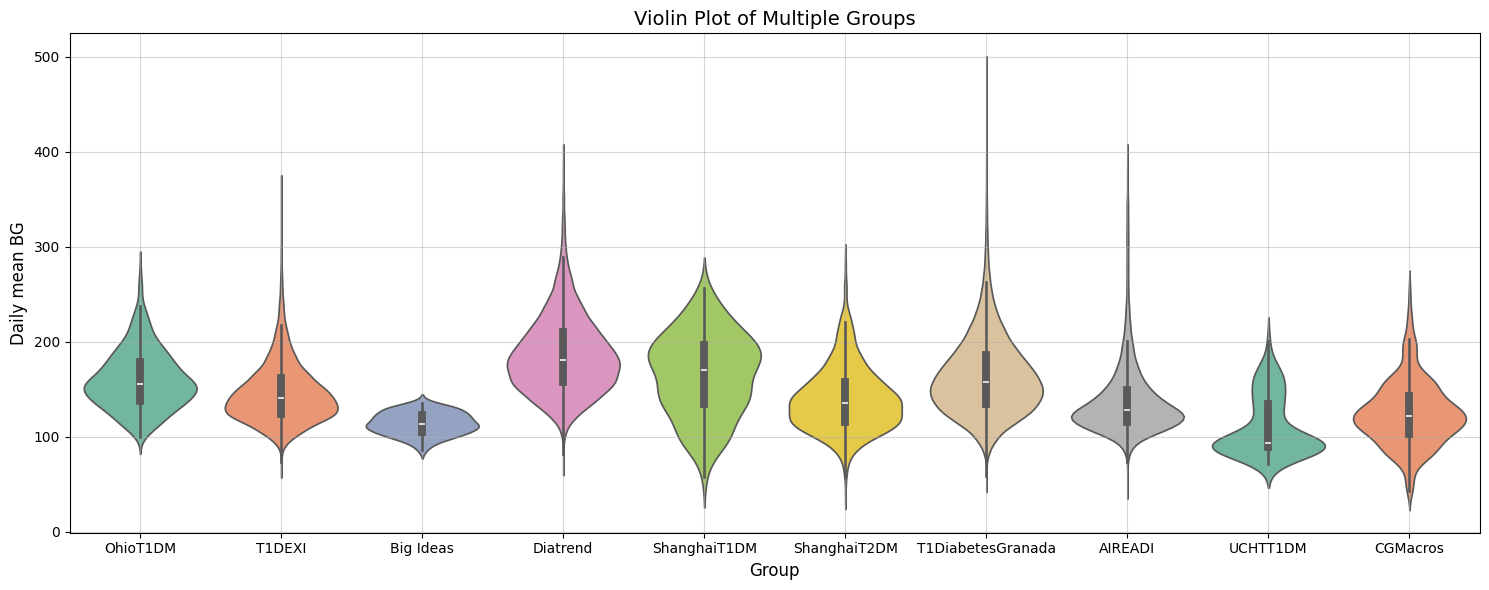

In [22]:
import seaborn as sns

# Put all data into a long-form DataFrame
df = pd.DataFrame({
    'value': total_mean_bg_ohio + total_mean_bg_t1dexi + total_mean_bg_BIL + total_mean_bg_Diatrend + total_mean_bg_shanghait1 + total_mean_bg_shanghait2 + total_mean_bg_t1diabetesgranada + total_mean_bg_aireadi + total_mean_bg_uchtt1dm + total_mean_bg_cgmacros,
    'group': ['OhioT1DM'] * len(total_mean_bg_ohio) + ['T1DEXI'] * len(total_mean_bg_t1dexi) + ['Big Ideas'] * len(total_mean_bg_BIL) + ['Diatrend'] * len(total_mean_bg_Diatrend) + ['ShanghaiT1DM'] * len(total_mean_bg_shanghait1) + ['ShanghaiT2DM'] * len(total_mean_bg_shanghait2) + ['T1DiabetesGranada'] * len(total_mean_bg_t1diabetesgranada) + ['AIREADI'] * len(total_mean_bg_aireadi) + ['UCHTT1DM'] * len(total_mean_bg_uchtt1dm) + ['CGMacros'] * len(total_mean_bg_cgmacros)
})

# Plot
plt.figure(figsize=(15, 6))
sns.violinplot(x='group', y='value', data=df, inner='box', palette='Set2')

# Labels and title
plt.xlabel('Group', fontsize=12)
plt.ylabel('Daily mean BG', fontsize=12)
plt.title('Violin Plot of Multiple Groups', fontsize=14)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

/var/folders/j5/tbqtlr256g5b8t969rk8d5kr0000gn/T/ipykernel_94931/446767464.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='group', y='value', data=df, inner='box', palette='Set2')


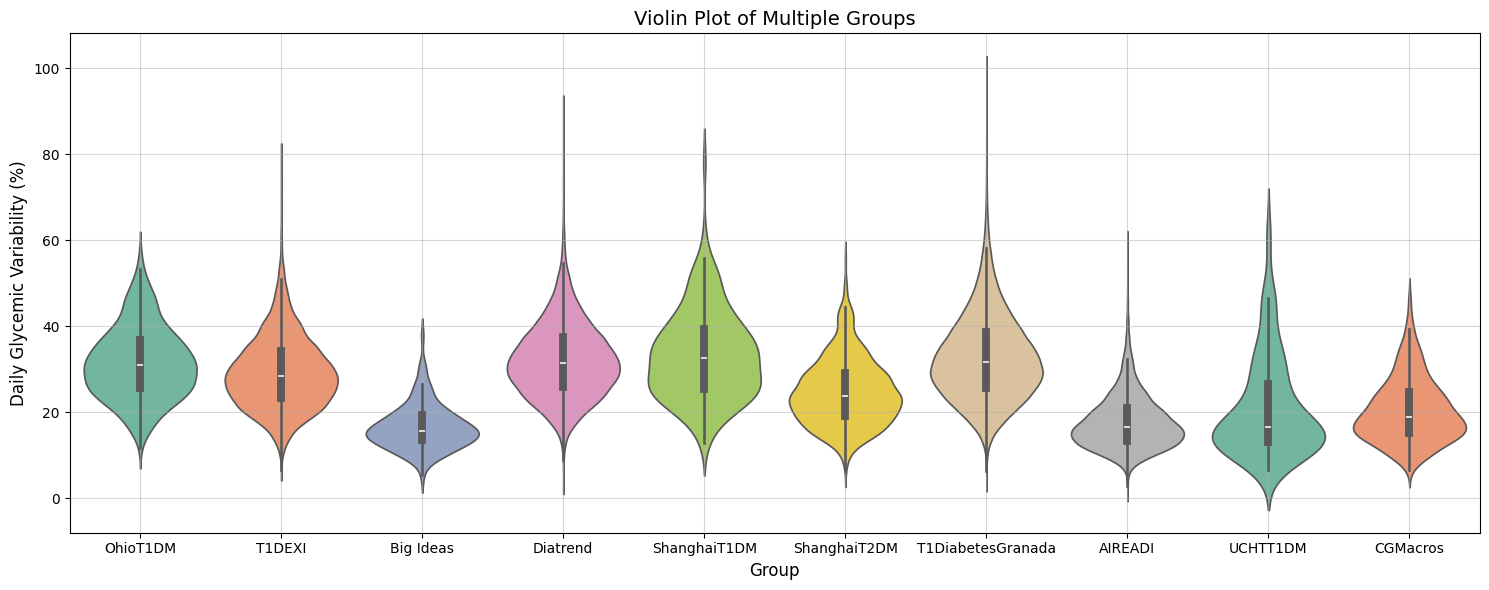

In [24]:
import seaborn as sns

# Put all data into a long-form DataFrame
df = pd.DataFrame({
    'value': total_gv_ohio + total_gv_t1dexi + total_gv_BIL + total_gv_Diatrend + total_gv_shanghait1 + total_gv_shanghait2 + total_gv_t1diabetesgranada + total_gv_aireadi + total_gv_uchtt1dm + total_gv_cgmacros,
    'group': ['OhioT1DM'] * len(total_gv_ohio) + ['T1DEXI'] * len(total_gv_t1dexi) + ['Big Ideas'] * len(total_gv_BIL) + ['Diatrend'] * len(total_gv_Diatrend) + ['ShanghaiT1DM'] * len(total_gv_shanghait1) + ['ShanghaiT2DM'] * len(total_gv_shanghait2) + ['T1DiabetesGranada'] * len(total_gv_t1diabetesgranada) + ['AIREADI'] * len(total_gv_aireadi) + ['UCHTT1DM'] * len(total_gv_uchtt1dm) + ['CGMacros'] * len(total_gv_cgmacros)
})

# Plot
plt.figure(figsize=(15, 6))
sns.violinplot(x='group', y='value', data=df, inner='box', palette='Set2')

# Labels and title
plt.xlabel('Group', fontsize=12)
plt.ylabel('Daily Glycemic Variability (%)', fontsize=12)
plt.title('Violin Plot of Multiple Groups', fontsize=14)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()